# Notebook 10 — 2D Laplace Transform

The **2D Laplace Transform** extends the 1D transform to functions of two variables:

$$F(s_1,s_2) = \int_0^\infty\int_0^\infty f(x,y)\,e^{-s_1 x - s_2 y}\,dx\,dy$$

Applications: 2D heat/diffusion, image processing, boundary-value problems.

**Covered:** numerical forward/inverse transform, analytic pairs, 2D convolution theorem, heat equation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

class Laplace2D:
    '''Numerical 2D Laplace Transform.'''

    def __init__(self, xy_max=15.0, n_pts=150):
        self.xy_max = xy_max
        self.n_pts  = n_pts

    def forward(self, f, s1, s2):
        '''F(s1,s2) via 2D trapezoidal rule. f(x,y) must accept arrays.'''
        x = np.linspace(0, self.xy_max, self.n_pts)
        y = np.linspace(0, self.xy_max, self.n_pts)
        X, Y = np.meshgrid(x, y, indexing='ij')
        try:
            F_mat = f(X, Y)
        except Exception:
            F_mat = np.vectorize(f)(X, Y)
        kernel = np.exp(-s1 * X - s2 * Y)
        integrand = F_mat * kernel
        integral_x = np.trapezoid(integrand, x, axis=0)
        return np.trapezoid(integral_x, y)

    def forward_grid(self, f, s1_vals, s2_vals):
        F = np.zeros((len(s1_vals), len(s2_vals)), dtype=complex)
        for i, s1 in enumerate(s1_vals):
            for j, s2 in enumerate(s2_vals):
                F[i, j] = self.forward(f, s1, s2)
        return F

    def inverse(self, F, x, y, gamma1=1.0, gamma2=1.0, omega_max=30.0, n_pts=200):
        '''Double Bromwich integral: f(x,y) = (1/2pij)^2 * double integral.'''
        w = np.linspace(-omega_max, omega_max, n_pts)
        s1_arr = gamma1 + 1j * w
        s2_arr = gamma2 + 1j * w
        S1, S2 = np.meshgrid(s1_arr, s2_arr, indexing='ij')
        Fmat = F(S1, S2)
        exp_mat = np.exp(S1 * x + S2 * y)
        integrand = Fmat * exp_mat
        integral = np.trapezoid(np.trapezoid(integrand, w, axis=1), w)
        return float(np.real(integral / (2 * np.pi)**2))

lt2d = Laplace2D()
print('Laplace2D initialised (integration limit=15, grid=150x150)')


Laplace2D initialised (integration limit=15, grid=150x150)


In [2]:
# Analytic pairs and verification
# f(x,y)            F(s1,s2)                 ROC
# u(x)u(y)          1/(s1*s2)                Re(si)>0
# exp(-ax)exp(-by)   1/((s1+a)(s2+b))        Re(si)>-ai
# xy u(x)u(y)        1/(s1^2 * s2^2)          Re(si)>0
# sin(ax)sin(by)u^2  ab/((s1^2+a^2)(s2^2+b^2)) Re(si)>0

def unit_step_2d(x, y):       return np.where((x>=0)&(y>=0), 1.0, 0.0)
def exp_product(x, y, a=1, b=1): return np.exp(-a*x-b*y)*np.where((x>=0)&(y>=0),1,0)
def ramp_product(x, y):        return x*y*np.where((x>=0)&(y>=0),1,0)
def sin_product(x, y, a=1, b=1): return np.sin(a*x)*np.sin(b*y)*np.where((x>=0)&(y>=0),1,0)

s1_t, s2_t = 2.0, 3.0
pairs = [
    ('u(x)u(y)',         lambda x,y: unit_step_2d(x,y),    1/(s1_t*s2_t)),
    ('exp(-x)exp(-y)',   lambda x,y: exp_product(x,y,1,1), 1/((s1_t+1)*(s2_t+1))),
    ('xy u(x)u(y)',      lambda x,y: ramp_product(x,y),    1/(s1_t**2*s2_t**2)),
    ('sin(x)sin(y)u^2',  lambda x,y: sin_product(x,y,1,1), 1/((s1_t**2+1)*(s2_t**2+1))),
]

print(f'Verification at s1={s1_t}, s2={s2_t}')
print(f'{"f(x,y)":<22} {"Numerical":>14} {"Analytic":>14} {"Rel error":>12}')
print('-'*66)
for name, f_func, ana in pairs:
    num = lt2d.forward(f_func, s1_t, s2_t)
    rel = abs(num-ana)/(abs(ana)+1e-15)
    print(f'{name:<22} {float(np.real(num)):>14.6f} {float(np.real(ana)):>14.6f} {rel:>12.2e}')


Verification at s1=2.0, s2=3.0
f(x,y)                      Numerical       Analytic    Rel error
------------------------------------------------------------------
u(x)u(y)                     0.168499       0.166667     1.10e-02
exp(-x)exp(-y)               0.085097       0.083333     2.12e-02
xy u(x)u(y)                  0.027475       0.027778     1.09e-02
sin(x)sin(y)u^2              0.019748       0.020000     1.26e-02


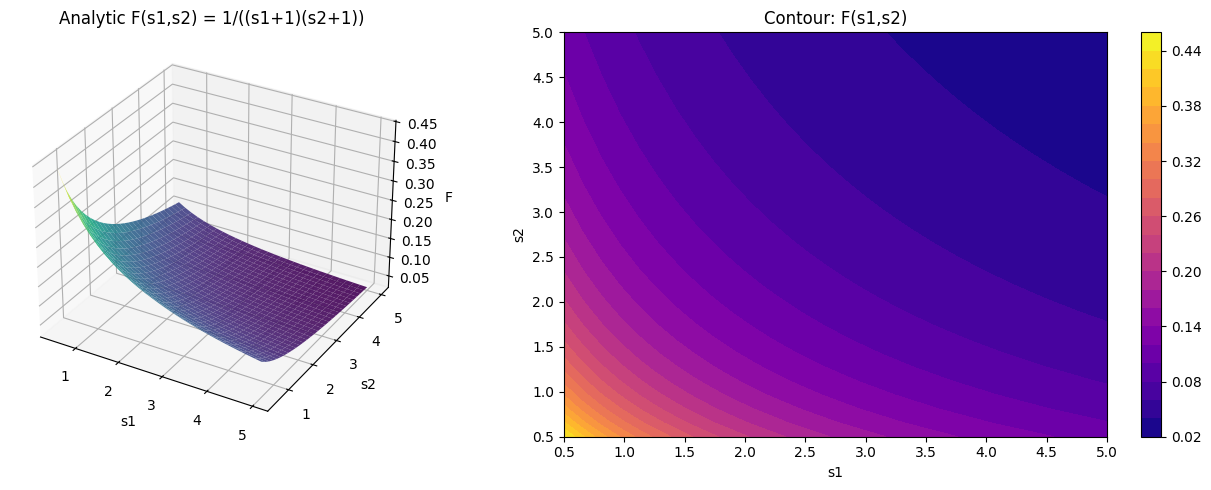

In [3]:
# Visualise F(s1,s2) surface
s1_range = np.linspace(0.5, 5.0, 30)
s2_range = np.linspace(0.5, 5.0, 30)
S1g, S2g = np.meshgrid(s1_range, s2_range, indexing='ij')
F_analytic = 1.0 / ((S1g+1)*(S2g+1))

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(S1g, S2g, F_analytic, cmap='viridis', alpha=0.9)
ax1.set_xlabel('s1'); ax1.set_ylabel('s2'); ax1.set_zlabel('F')
ax1.set_title('Analytic F(s1,s2) = 1/((s1+1)(s2+1))')

ax2 = fig.add_subplot(122)
cp = ax2.contourf(S1g, S2g, F_analytic, 20, cmap='plasma')
plt.colorbar(cp, ax=ax2)
ax2.set_xlabel('s1'); ax2.set_ylabel('s2')
ax2.set_title('Contour: F(s1,s2)')
plt.tight_layout(); plt.show()


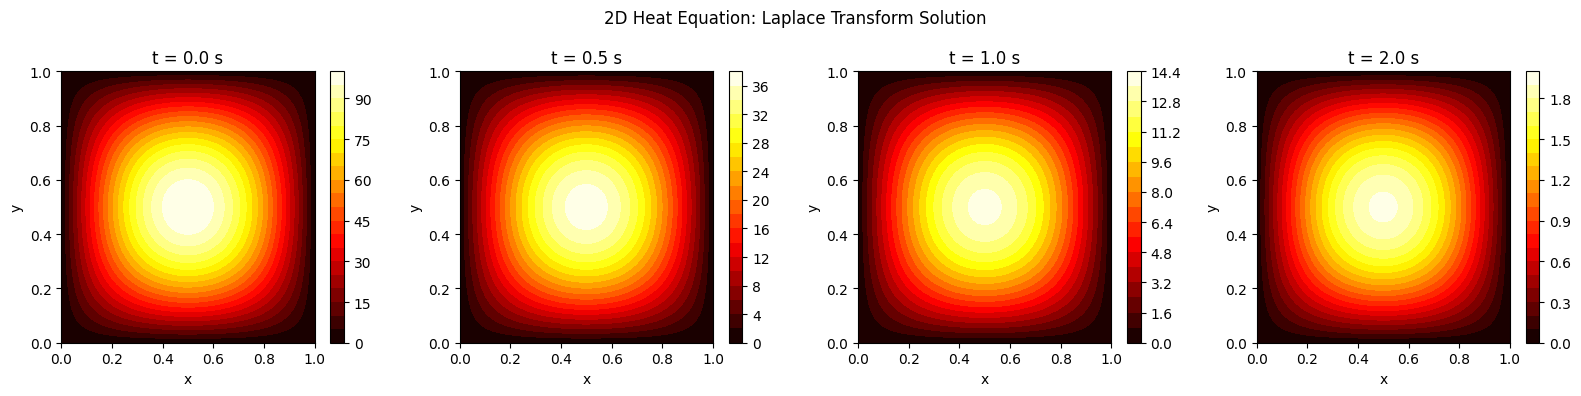

Decay constant lambda = 1.9739  =>  time constant tau = 0.5066 s
Peak at t=1: 13.89 C  (started 100 C)


In [4]:
# 2D Heat Equation solved via Laplace Transform
# PDE: du/dt = alpha*(d^2u/dx^2 + d^2u/dy^2)
# IC:  u(x,y,0) = T0*sin(pi*x/L)*sin(pi*y/L)
# BC:  u=0 on boundaries
# Exact: u(x,y,t) = T0*sin(pi*x/L)*sin(pi*y/L)*exp(-2*alpha*(pi/L)^2*t)

alpha, L, T0 = 0.1, 1.0, 100.0
lam = 2*alpha*(np.pi/L)**2

def heat_sol(x, y, t):
    return T0 * np.sin(np.pi*x/L) * np.sin(np.pi*y/L) * np.exp(-lam*t)

x_r = np.linspace(0, L, 60)
y_r = np.linspace(0, L, 60)
X2, Y2 = np.meshgrid(x_r, y_r)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, t_snap in zip(axes, [0.0, 0.5, 1.0, 2.0]):
    cp = ax.contourf(X2, Y2, heat_sol(X2, Y2, t_snap), 20, cmap='hot')
    plt.colorbar(cp, ax=ax)
    ax.set_title(f't = {t_snap:.1f} s'); ax.set_xlabel('x'); ax.set_ylabel('y')

plt.suptitle('2D Heat Equation: Laplace Transform Solution')
plt.tight_layout(); plt.show()
print(f'Decay constant lambda = {lam:.4f}  =>  time constant tau = {1/lam:.4f} s')
print(f'Peak at t=1: {heat_sol(0.5,0.5,1.0):.2f} C  (started {T0:.0f} C)')


In [5]:
# 2D Transform Properties Summary
props = {
    'Linearity':      'L2{af+bg} = aF + bG',
    'x-shift':        'L2{f(x-a,y)} = exp(-a*s1)*F(s1,s2)',
    'y-shift':        'L2{f(x,y-b)} = exp(-b*s2)*F(s1,s2)',
    'x-derivative':   'L2{df/dx} = s1*F - F(0,s2)',
    'y-derivative':   'L2{df/dy} = s2*F - F(s1,0)',
    '2D convolution': 'L2{f**g} = F(s1,s2)*G(s1,s2)',
    'Separability':   'If f(x,y)=f1(x)*f2(y) then F=F1(s1)*F2(s2)',
    'Scaling':        'L2{f(ax,by)} = F(s1/a,s2/b)/(a*b)',
}
print('='*60)
print('2D LAPLACE TRANSFORM - KEY PROPERTIES')
print('='*60)
for k, v in props.items():
    print(f'  {k:<18}  {v}')


2D LAPLACE TRANSFORM - KEY PROPERTIES
  Linearity           L2{af+bg} = aF + bG
  x-shift             L2{f(x-a,y)} = exp(-a*s1)*F(s1,s2)
  y-shift             L2{f(x,y-b)} = exp(-b*s2)*F(s1,s2)
  x-derivative        L2{df/dx} = s1*F - F(0,s2)
  y-derivative        L2{df/dy} = s2*F - F(s1,0)
  2D convolution      L2{f**g} = F(s1,s2)*G(s1,s2)
  Separability        If f(x,y)=f1(x)*f2(y) then F=F1(s1)*F2(s2)
  Scaling             L2{f(ax,by)} = F(s1/a,s2/b)/(a*b)
